# Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)


### Objetivo
En esta evaluación, implementaremos un modelo basado en arquitecturas de Transformers para una tarea de procesamiento de lenguaje natural (NLP), utilizando el dataset **DailyDialog**. Este conjunto de datos de diálogos permite que el modelo practique en generación de texto y comprensión de contexto en interacciones cotidianas.

Usaremos TensorFlow para construir un modelo transformer básico con las siguientes características:
- **Encoder-Decoder**: para procesar la entrada y generar salida secuencial.
- **Atención Multi-cabezal**: para capturar dependencias a largo plazo en el diálogo.

Al final, evaluaremos el modelo utilizando métricas específicas de NLP, como BLEU o ROUGE.


## 1. Carga y Exploración del Dataset: DailyDialog

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/validation.csv

--2025-06-22 05:08:51--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6233555 (5.9M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]   5.94M  --.-KB/s    in 0.09s   

2025-06-22 05:08:51 (65.9 MB/s) - ‘train.csv’ saved [6233555/6233555]

--2025-06-22 05:08:51--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 561656 (548

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import ast
import re
from collections import Counter
from tensorflow.keras import layers, Model
import math
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.losses import CategoricalCrossentropy

from tensorflow.keras.optimizers import AdamW

!pip install nltk
import nltk

from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.bleu_score import sentence_bleu

In [3]:
# ——— Máscaras de padding y look-ahead ———
def create_padding_mask(seq):
    # seq: one-hot de un solo ejemplo, shape (MAX_LEN, VOCAB_SIZE)
    # 1) IDs de token:
    seq_ids = tf.argmax(seq, axis=-1)                    # → (MAX_LEN,)
    # 2) máscara: 1 donde sea pad_id
    mask = tf.cast(tf.equal(seq_ids, pad_id), tf.float32)  # → (MAX_LEN,)
    # 3) darle forma (1, 1, MAX_LEN) para que .batch() genere (BATCH_SZ, 1, 1, MAX_LEN)
    return mask[tf.newaxis, tf.newaxis, :]




def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # (size, size)

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
validation = pd.read_csv('validation.csv')

In [5]:
train

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]
...,...,...,...
11113,"['Hello , I bought a pen in your shop just bef...",[1 1 1 2 3 2 1 4 1],[0 4 0 0 0 0 0 0 4]
11114,['Do you have any seats available ? ' ' Yes . ...,[2 1 2 1 3 4],[0 0 0 0 0 4]
11115,"['Uncle Ben , how did the Forbidden City get t...",[2 1 2 1 1 1 1 1 2 1 2 1 2 1 3 4],[0 0 6 0 6 0 0 0 0 0 0 0 0 0 4 0]
11116,"['May I help you , sir ? ' ' I want a pair of ...",[2 3 4 3],[0 0 0 0]


### Tokenización

In [6]:
# Función de parseo de "dialog" a lista de utterances
def parse_dialog(s: str):
    if not isinstance(s, str):
        return []
    s = s.replace('\n',' ').strip()
    if s.startswith('[') and s.endswith(']'):
        inner = s[1:-1]
    else:
        inner = s
    inner = re.sub(r"'\s+'", "', '", inner)
    inner = re.sub(r'"\s+"', '", "', inner)
    try:
        parsed = ast.literal_eval(f'[{inner}]')
        return [u.strip() for u in parsed if isinstance(u,str) and u.strip()]
    except:
        parts = re.split(r'\s{2,}', inner)
        return [p.strip(" '\"") for p in parts if p.strip()]

In [7]:
# Aplicar parseo y extraer pares turno_i → turno_{i+1}
def extract_pairs(df):
    inputs, targets = [], []
    df['dialog_parsed'] = df['dialog'].apply(parse_dialog)
    for conv in df['dialog_parsed']:
        for u,v in zip(conv, conv[1:]):
            inputs.append(u)
            targets.append(v)
    return inputs, targets

In [8]:
train_inputs, train_targets         = extract_pairs(train)
validation_inputs, validation_targets = extract_pairs(validation)
test_inputs, test_targets           = extract_pairs(test)

In [9]:
print("Ejemplos parseados:", train.loc[0,'dialog_parsed'][:3])
print("Número de pares (train / val / test):",
      len(train_inputs), "/", len(validation_inputs), "/", len(test_inputs))

Ejemplos parseados: ['Say , Jim , how about going for a few beers after dinner ?', 'You know that is tempting but is really not good for our fitness .', "What do you mean ? It will help us to relax .  Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?"]
Número de pares (train / val / test): 51341 / 4774 / 4544


El siguiente paso es convertir esos pares de strings en tensores numéricos “one-hot” para poder alimentarlos al Transformer.

In [10]:
# Parámetros
MAX_LEN   = 50
MIN_FREQ  = 1
BATCH_SZ  = 64

# Construir vocabulario
counter = Counter()
for s in train_inputs + train_targets:
    words = re.findall(r"\b[a-zA-Z']+\b", s.lower())  # permite apóstrofes
    counter.update(words)

# palabras frecuentes ≥ MIN_FREQ
voc = [w for w,f in counter.items() if f>=MIN_FREQ]
# tokens especiales al inicio
vocab = ['<pad>','<unk>','<bos>','<eos>'] + sorted(voc)
vocab_size = len(vocab)
word2idx = {w:i for i,w in enumerate(vocab)}
pad_id, unk_id, bos_id, eos_id = 0,1,2,3

vectorizer = tf.keras.layers.TextVectorization(
    standardize=None,
    split='whitespace',
    vocabulary=vocab,  # Sin max_tokens!
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Función que convierte una utterance en one-hot (MAX_LEN, vocab_size)
def encode_onehot(text):
    seq = vectorizer(tf.expand_dims(text,0))
    seq = tf.squeeze(seq,0)
    seq = tf.concat([[bos_id], seq, [eos_id]], axis=0)[:MAX_LEN]
    seq = tf.pad(seq, [[0, MAX_LEN - tf.shape(seq)[0]]], constant_values=pad_id)
    return tf.one_hot(seq, depth=vocab_size)


In [11]:
# Prueba rápida
sample = train_inputs[0]
oh = encode_onehot(sample)
print("Utterance:", sample)
print("One-hot shape:", oh.shape)   # → (MAX_LEN, vocab_size)
print("Primeros índices:", tf.argmax(oh, axis=-1)[:10].numpy())

Utterance: Say , Jim , how about going for a few beers after dinner ?
One-hot shape: (50, 17232)
Primeros índices: [   2    1    1    1    1 7329   31 6475 5977    6]


A continuación vamos a crear un tf.data.Dataset que:

* Tome tus listas de pares train_inputs y train_targets.

* Aplique encode_onehot a cada utterance de entrada y de salida.

* Agrupe en batches de tamaño BATCH_SZ produciendo tuplas (x, y) con x, y de forma (MAX_LEN, vocab_size).

In [12]:
def map_to_transformer(src, tgt):
    # 1) Encoder one-hot
    enc = encode_onehot(src)  # (MAX_LEN, vocab_size)

    # 2) Decoder input (IDs→one-hot)
    ids = vectorizer(tf.expand_dims(tgt,0))
    ids = tf.squeeze(ids,0)
    dec_in_ids = tf.concat([[bos_id], ids[:-1]], axis=0)
    dec_in_ids = tf.pad(dec_in_ids,
                        [[0, MAX_LEN - tf.shape(dec_in_ids)[0]]],
                        constant_values=pad_id)
    dec_in = tf.one_hot(dec_in_ids, depth=vocab_size)

    # 3) Decoder target
    dec_tgt_ids = tf.concat([ids, [eos_id]], axis=0)[:MAX_LEN]
    dec_tgt_ids = tf.pad(dec_tgt_ids,
                         [[0, MAX_LEN - tf.shape(dec_tgt_ids)[0]]],
                         constant_values=pad_id)
    dec_tgt = tf.one_hot(dec_tgt_ids, depth=vocab_size)

    # 4) Máscaras de padding
    enc_mask = create_padding_mask(enc)    # → (batch,1,1,MAX_LEN)
    dec_mask = create_padding_mask(dec_in) # → (batch,1,1,MAX_LEN)

    # 5) Ahora devolvemos las 4 entradas al transformer
    return (enc, dec_in, enc_mask, dec_mask), dec_tgt


In [13]:
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_inputs, train_targets))
    .shuffle(1000)
    .map(map_to_transformer, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SZ, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((validation_inputs, validation_targets))
    .map(map_to_transformer, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SZ, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

## 2. Implementación del Modelo Transformer

In [14]:
# Hiperparámetros del Transformer
MAX_LEN    = 50
VOCAB_SIZE = vocab_size   # definido antes
D_MODEL    = 128
NUM_HEADS  = 8
DFF        = 512
NUM_LAYERS = 2
DROPOUT    = 0.1

In [15]:
# Positional Encoding como capa
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()
        pos = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]
        i   = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle_rates = 1 / tf.pow(10000., (2 * (i//2)) / tf.cast(d_model, tf.float32))
        angle_rads  = pos * angle_rates
        pe = tf.where(tf.cast(i, tf.int32) % 2 == 0,
                      tf.sin(angle_rads),
                      tf.cos(angle_rads))
        self.pe = pe[tf.newaxis, ...]  # (1, max_len, d_model)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

In [16]:
# Bloque de Encoder Layer
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.25, name=None):
        super().__init__(name=name)
        self.mha   = layers.MultiHeadAttention(num_heads, d_model//num_heads, dropout=dropout)
        self.ffn   = tf.keras.Sequential([
                       layers.Dense(dff), layers.Activation('gelu'),
                       layers.Dense(d_model)
                     ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, padding_mask=None):
        attn = self.mha(x, x, x, attention_mask=padding_mask)
        attn = self.drop1(attn)
        out1 = self.norm1(x + attn)
        ffn  = self.ffn(out1)
        ffn  = self.drop2(ffn)
        return self.norm2(out1 + ffn)

In [17]:
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1, name=None):
        super().__init__(name=name)
        self.mha1 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        self.mha2 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='gelu'),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)
        self.drop3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_output,
             padding_mask=None,
             dec_padding_mask=None):
        # 1) Build look-ahead boolean mask: True where j <= i
        seq_len = tf.shape(x)[1]
        causal = tf.linalg.band_part(
            tf.ones((seq_len, seq_len), dtype=tf.bool), -1, 0
        )  # (seq_len, seq_len)
        causal = causal[tf.newaxis, tf.newaxis, :, :]  # (1,1,seq_len,seq_len)

        # 2) Convert decoder padding mask to boolean: True where not pad
        # dec_padding_mask is float 0.0 or 1.0
        dec_pad_bool = tf.equal(dec_padding_mask, 0.0)  # (batch,1,1,seq_len)

        # 3) Combine causal and padding masks
        # result True only when both allow attention
        combined_mask = tf.logical_and(dec_pad_bool, causal)  # (batch,1,seq_len,seq_len)

        # 4) Self-attention with combined boolean mask
        attn1 = self.mha1(x, x, x, attention_mask=combined_mask)
        attn1 = self.drop1(attn1)
        out1 = self.norm1(x + attn1)

        # 5) Cross-attention (uses encoder padding_mask)
        attn2 = self.mha2(
            out1, enc_output, enc_output,
            attention_mask=padding_mask
        )
        attn2 = self.drop2(attn2)
        out2 = self.norm2(out1 + attn2)

        # 6) Feed-forward network
        ffn_out = self.ffn(out2)
        ffn_out = self.drop3(ffn_out)
        return self.norm3(out2 + ffn_out)

In [18]:
def masked_categorical_crossentropy(y_true, y_pred):
    """
    y_true: one-hot true (batch, seq, vocab)
    y_pred: logits       (batch, seq, vocab)
    """
    # 1) Crea la máscara: True donde el token no es PAD
    true_ids = tf.argmax(y_true, axis=-1)                  # (batch, seq)
    mask     = tf.cast(tf.not_equal(true_ids, pad_id), tf.float32)  # 1.0 para real, 0.0 para pad

    # 2) Cálculo punto a punto de la crossentropy
    per_token_loss = tf.keras.losses.categorical_crossentropy(
        y_true, y_pred, from_logits=True
    )   # (batch, seq)

    # 3) Aplica la máscara y promedia solo sobre tokens reales
    loss = tf.reduce_sum(per_token_loss * mask) / tf.reduce_sum(mask)
    return loss


In [19]:
# 1) Definir Inputs
enc_input = Input((MAX_LEN, VOCAB_SIZE), name="enc_input")
dec_input = Input((MAX_LEN, VOCAB_SIZE), name="dec_input")
enc_mask  = Input((1,1,MAX_LEN),      name="enc_padding_mask")
dec_mask  = Input((1,1,MAX_LEN),      name="dec_padding_mask")

# 2) Proyección one-hot → d_model + Positional Encoding
enc_proj = layers.Dense(D_MODEL)(enc_input)
enc_pos  = PositionalEncoding(D_MODEL)(enc_proj)
dec_proj = layers.Dense(D_MODEL)(dec_input)
dec_pos  = PositionalEncoding(D_MODEL)(dec_proj)

# 3) Encoder stack con padding_mask
x = enc_pos
for i in range(NUM_LAYERS):
    x = EncoderLayer(
        d_model=D_MODEL, num_heads=NUM_HEADS, dff=DFF, dropout=DROPOUT,
        name=f"enc_layer_{i}"
    )(x, padding_mask=enc_mask)
enc_out = x

# 4) Decoder stack usando la máscara interna causal de Keras y padding_mask
y = dec_pos
for i in range(NUM_LAYERS):
    y = DecoderLayer(
        d_model=D_MODEL, num_heads=NUM_HEADS, dff=DFF, dropout=DROPOUT,
        name=f"dec_layer_{i}"
    )(y, enc_out, padding_mask=enc_mask, dec_padding_mask=dec_mask)

# 5) Proyección final a vocab logits
logits = layers.Dense(VOCAB_SIZE)(y)

# 6) Montar el modelo
transformer = Model(
    inputs=[enc_input, dec_input, enc_mask, dec_mask],
    outputs=logits,
    name="transformer"
)

In [20]:
loss_fn   = tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1)
optimizer = AdamW(weight_decay=1e-5, learning_rate=1e-4)

transformer.compile(
    optimizer=optimizer,
    loss=masked_categorical_crossentropy
)
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_input           │ (None, 50, 17232) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 128)   │  2,205,824 │ enc_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_input           │ (None, 50, 17232) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 50, 128)   │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_padding_mask    │ (None, 1, 1, 50)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 128)   │  2,205,824 │ dec_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layer_0         │ (None, 50, 128)   │    198,272 │ positional_encod… │
│ (EncoderLayer)      │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 50, 128)   │          0 │ dense_1[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layer_1         │ (None, 50, 128)   │    198,272 │ enc_layer_0[0][0… │
│ (EncoderLayer)      │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_padding_mask    │ (None, 1, 1, 50)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layer_0         │ (None, 50, 128)   │    264,576 │ positional_encod… │
│ (DecoderLayer)      │                   │            │ enc_layer_1[0][0… │
│                     │                   │            │ dec_padding_mask… │
│                     │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layer_1         │ (None, 50, 128)   │    264,576 │ dec_layer_0[0][0… │
│ (DecoderLayer)      │                   │            │ enc_layer_1[0][0… │
│                     │                   │            │ dec_padding_mask… │
│                     │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 50, 17232) │  2,222,928 │ dec_layer_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,560,272 (28.84 MB)

 Trainable params: 7,560,272 (28.84 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento del Modelo

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


In [22]:
def call_transformer(model, enc_oh, dec_oh):
    enc_mask = create_padding_mask(enc_oh)
    dec_mask = create_padding_mask(dec_oh)
    return model([enc_oh, dec_oh, enc_mask, dec_mask], training=False)


In [23]:
history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 115s 81ms/step - loss: 7.0045 - val_loss: 4.7707
Epoch 2/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.7908 - val_loss: 4.5084
Epoch 3/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.5388 - val_loss: 4.2583
Epoch 4/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.3190 - val_loss: 4.1427
Epoch 5/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.2010 - val_loss: 4.0565
Epoch 6/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.1161 - val_loss: 4.0061
Epoch 7/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 4.0502 - val_loss: 3.9476
Epoch 8/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 3.9890 - val_loss: 3.9035
Epoch 9/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 3.9339 - val_loss: 3.8721
Epoch 10/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 62s 77ms/step - loss: 3.8846 - val_loss: 3.8460


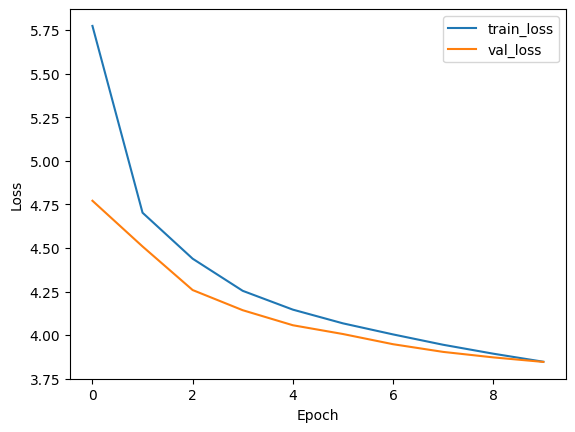

In [25]:
# Graficar pérdida
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Evaluación del Modelo

In [26]:
# -- 1) Función auxiliar para invocar el Transformer con sus 3 inputs --
def call_transformer(model, enc_oh, dec_oh):
    """
    Llama a model([enc_oh, dec_oh, enc_mask]) construyendo enc_mask automáticamente.
    enc_oh: tensor (1, MAX_LEN, vocab_size)
    dec_oh: tensor (1, MAX_LEN, vocab_size)
    """
    # create_padding_mask maneja batch de tamaño 1: devuelve (1,1,1,MAX_LEN)
    enc_mask = create_padding_mask(enc_oh)      # (1,1,1,MAX_LEN)
    # máscara decoder
    dec_mask = create_padding_mask(dec_oh)      # (1,1,1,MAX_LEN)
    # ¡ahora pasamos las cuatro entradas!
    return model([enc_oh, dec_oh, enc_mask, dec_mask], training=False)

# -- 2) Diagnóstico paso a paso del modelo --
def diagnose_model_output(model, source_text, max_steps=5):
    """
    Muestra para cada paso las top-5 predicciones (palabra, probabilidad).
    """
    print(f"Diagnosticando: '{source_text}'")
    # 1) One-hot + batch
    enc_oh = tf.expand_dims(encode_onehot(source_text), 0)  # (1,MAX_LEN,V)
    dec_ids = [bos_id]

    for step in range(max_steps):
        # 2) Construir decoder-input one-hot hasta posición `step`
        pad_count = MAX_LEN - len(dec_ids)
        curr_ids = dec_ids + [pad_id]*pad_count
        dec_oh   = tf.one_hot([curr_ids], depth=vocab_size)    # (1,MAX_LEN,V)

        # 3) Obtener logits y enmascarar PAD/BOS
        logits = call_transformer(model, enc_oh, dec_oh)       # (1,MAX_LEN,V)
        next_logits = logits[0, step, :]
        # Penalizar PAD y BOS
        mask = tf.ones_like(next_logits)
        mask = tf.tensor_scatter_nd_update(mask, [[pad_id]], [-1e9])
        mask = tf.tensor_scatter_nd_update(mask, [[bos_id]], [-1e9])
        next_logits += mask

        # 4) Top-5
        probs    = tf.nn.softmax(next_logits).numpy()
        top_idx  = tf.argsort(probs, direction='DESCENDING')[:5].numpy()
        print(f"Paso {step}:")
        for rank, idx in enumerate(top_idx, 1):
            word = vocab[idx] if idx < len(vocab) else f"ID_{idx}"
            print(f"  {rank}. {word} (prob: {probs[idx]:.4f})")

        # 5) Escoger siguiente token
        next_id = int(tf.argmax(next_logits))
        dec_ids.append(next_id)
        if next_id == eos_id:
            break

    print("Secuencia de IDs generada:", dec_ids)


In [27]:
# -- 3) Generación greedy (argmax) corregida --
def generate_response_tf(model, source_text, max_len=MAX_LEN):
    """
    Decodificación greedy: argmax paso a paso.
    Devuelve lista de palabras (sin <bos>/<eos>).
    """
    enc_oh = tf.expand_dims(encode_onehot(source_text), 0)
    dec_ids = [bos_id]

    for step in range(max_len-1):
        pad_count = max_len - len(dec_ids)
        curr_ids = dec_ids + [pad_id]*pad_count
        dec_oh   = tf.one_hot([curr_ids], depth=vocab_size)

        logits    = call_transformer(model, enc_oh, dec_oh)
        next_logits = logits[0, step, :]
        # Penalizar PAD/BOS igual que arriba
        mask = tf.ones_like(next_logits)
        mask = tf.tensor_scatter_nd_update(mask, [[pad_id]], [-1e9])
        mask = tf.tensor_scatter_nd_update(mask, [[bos_id]], [-1e9])
        next_logits += mask

        next_id = int(tf.argmax(next_logits))
        dec_ids.append(next_id)
        if next_id == eos_id:
            break

    # Limpiar BOS/EOS y convertir a palabras
    output_ids = dec_ids[1:]
    if output_ids and output_ids[-1] == eos_id:
        output_ids = output_ids[:-1]
    return [vocab[i] for i in output_ids
            if i < len(vocab) and vocab[i] not in ['<pad>','<unk>','<bos>','<eos>']]


In [28]:
# -- 4) Generación por sampling con temperatura --
def generate_response_sampling(model, source_text,
                               max_len=MAX_LEN, temperature=1.0):
    """
    Muestreo paso a paso: liga logits con temperatura y sample.
    """
    enc_oh = tf.expand_dims(encode_onehot(source_text), 0)
    dec_ids = [bos_id]

    for step in range(max_len-1):
        pad_count = max_len - len(dec_ids)
        curr_ids = dec_ids + [pad_id]*pad_count
        dec_oh   = tf.one_hot([curr_ids], depth=vocab_size)

        logits = call_transformer(model, enc_oh, dec_oh)[0, step, :] / temperature
        # Penalizar PAD/BOS
        mask = tf.ones_like(logits)
        mask = tf.tensor_scatter_nd_update(mask, [[pad_id]], [-1e9])
        mask = tf.tensor_scatter_nd_update(mask, [[bos_id]], [-1e9])
        logits += mask

        next_id = int(tf.random.categorical([logits], 1)[0,0])
        dec_ids.append(next_id)
        if next_id == eos_id:
            break

    output_ids = dec_ids[1:]
    if output_ids and output_ids[-1] == eos_id:
        output_ids = output_ids[:-1]
    return [vocab[i] for i in output_ids
            if i < len(vocab) and vocab[i] not in ['<pad>','<unk>','<bos>','<eos>']]


In [29]:
# Primero, diagnostica qué está pasando
sample_inp = train_inputs[:10]
diagnose_model_output(transformer, sample_inp)

# Luego prueba la generación corregida
print("Generación corregida:", " ".join(generate_response_tf(transformer, sample_inp)))

# O prueba con sampling
print("Generación con sampling:", " ".join(generate_response_sampling(transformer, sample_inp, temperature=0.6)))

Diagnosticando: 'Say , Jim , how about going for a few beers after dinner ?'
Paso 0:
  1. <unk> (prob: 0.9783)
  2. yesterday (prob: 0.0017)
  3. you'ii (prob: 0.0012)
  4. that'll (prob: 0.0009)
  5. what'll (prob: 0.0008)
Paso 1:
  1. <unk> (prob: 0.3798)
  2. you'ii (prob: 0.0662)
  3. haven (prob: 0.0177)
  4. isa (prob: 0.0173)
  5. dock (prob: 0.0166)
Paso 2:
  1. <unk> (prob: 0.4623)
  2. sa (prob: 0.0642)
  3. ma'am (prob: 0.0305)
  4. it'll (prob: 0.0241)
  5. you'ii (prob: 0.0175)
Paso 3:
  1. <unk> (prob: 0.2942)
  2. you'ii (prob: 0.0448)
  3. haven (prob: 0.0339)
  4. dock (prob: 0.0211)
  5. canada (prob: 0.0199)
Paso 4:
  1. <unk> (prob: 0.3634)
  2. sa (prob: 0.0356)
  3. ma'am (prob: 0.0314)
  4. you'ii (prob: 0.0233)
  5. haven (prob: 0.0229)
Secuencia de IDs generada: [2, 1, 1, 1, 1, 1]
Generación corregida: 
Generación con sampling: thinking abraham that'll lo beached rights withdrawal aa feynman dayton


## 5. Ajuste de Hiperparámetros

In [ ]:

# Probar diferentes configuraciones de hiperparámetros
# Ejemplo: modificar num_heads, ff_dim, número de capas

# Documentar los resultados y evaluar cada configuración
# for num_heads in [2, 4, 8]:
#     for ff_dim in [32, 64, 128]:
#         # Redefinir y entrenar modelo con nuevos hiperparámetros
#         # Registrar métricas y comparar rendimiento


## 6. Presentación de Resultados y Conclusiones


En esta sección, resumiremos los resultados obtenidos, mostrando cómo los ajustes de los hiperparámetros impactaron en el rendimiento del modelo.
- **Resultados Finales**: Comparación de BLEU, ROUGE, y otras métricas para cada configuración.
- **Conclusiones**: Reflexión sobre el proceso, dificultades encontradas y aprendizajes obtenidos.

¡Gracias por revisar nuestro proyecto! Esperamos que esta implementación demuestre nuestro dominio en el uso de transformers para NLP.
